In [ ]:
# ── Standard numerical / plotting imports ──────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# mumax3PP: post-processing helpers for Mumax3 micromagnetic simulations
import mumax3PP.ovf as ovf                          # Read OVF magnetisation files output by Mumax3
import mumax3PP.parameters as parameters            # Parse simulation parameters / headers
import mumax3PP.fft_across_xyzm as FFT_across_xyzm # FFT helpers along spatial / magnetisation axes

import matplotlib.colors as colors
from matplotlib import mlab, cm

# Curve fitting and signal processing
from scipy.optimize import curve_fit   # Non-linear least-squares fitting
from scipy.signal import hilbert       # Analytic signal (envelope) via Hilbert transform
from scipy.signal import argrelextrema # Local extrema detection

import glob                            # File-path pattern matching
from os import path
import time
from IPython.display import clear_output  # Refresh output cell in loops

%matplotlib inline

# ── Convenience aliases for frequently used math symbols ───────────────────────
sqrt = np.sqrt
pi   = np.pi
exp  = np.exp
sin  = np.sin
cos  = np.cos
mu0  = np.pi * 4e-07   # Vacuum permeability μ₀ (H/m)


In [3]:
# ── Utility and model functions ────────────────────────────────────────────────

def findNearest(array, value):
    """Return the index and value of the element in *array* closest to *value*."""
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]


def lin_fun(x, a, b):
    """Simple linear model: f(x) = a*x + b.
    Used to fit a slowly varying (nearly linear) amplitude envelope."""
    return a * x + b


def fun(x, x0, A, K):
    """Exponential decay model: f(x) = A * exp(-K*(x - x0)).
    Used to fit the spatial decay of the edge-mode amplitude away from the Py edge.
    Parameters:
        x0 – origin offset (m)
        A  – prefactor (amplitude at x = x0)
        K  – decay rate (m⁻¹); negative K gives decay for x < x0
    """
    return A * np.exp(-K * (x - x0))


# def wave(x, x0, A, alpha, k, phi):
#     """Damped sinusoid (disabled). Previously used when the propagating
#     oscillation needed an explicit amplitude decay factor alpha."""
#     return A*np.exp(-alpha*(x-x0))*np.sin(k*(x-x0)+phi)


def wave(x, x0, A, k, phi):
    """Undamped sinusoid: f(x) = A * sin(k*(x - x0) + phi).
    Used to fit the oscillatory component of the edge mode along the y-direction.
    Parameters:
        x0  – spatial origin
        A   – amplitude
        k   – wave-vector (rad/m)
        phi – initial phase (rad)
    """
    return A * np.sin(k * (x - x0) + phi)


def B_demag_fun(x, A, h):
    """Analytical demagnetising field profile at the edge of a semi-infinite thin film.
    Derived from magnetostatics for a film of thickness h; the field decays from
    the edge (x = 0) into the interior of the Py layer.
    Parameters:
        x – distance from the edge (nm or m, consistent with h)
        A – overall field scale (proportional to μ₀·Ms)
        h – film thickness (same units as x)
    Returns:
        well – transverse demagnetising field component B_y^d(x)
    """
    #     h = 20    # film thickness (nm) – set via curve_fit
    #     A = -600  # field amplitude (mT) – set via curve_fit
    well = A * (
        (1 / 2)
        - (1 / np.pi) * np.arctan(x / h)
        - (x / (2 * np.pi * h)) * np.log(1 + (h / x) ** 2)
    )
    return well


In [1015]:
# ── Simulation excitation parameters ──────────────────────────────────────────
B0 = 0.3        # Applied bias field magnitude (T); 300 mT
stimAmp = 0.01 * B0  # RF excitation amplitude = 1% of B0 (used as driving field in Mumax3)
10 * stimAmp    # Quick sanity-check: display 10× stimAmp (3 mT)


0.03

In [1016]:
# ── Load a single OVF magnetisation file ──────────────────────────────────────
# Path to a Mumax3 output directory for a specific edge-mode simulation:
#   B = 300 mT bias field, excitation frequency = 11.0 GHz, amplitude = 0.003·B0
path0 = 'D:\\mumax3\\inelastic_scattering\\k_pos\\edge_modes\\B_300mT_edge_f_11.0GHz_amp_0.0030.out'

# Load OVF files from the last snapshot (tStart=-100 discards early transients)
parms = parameters.ovfParms(head='m', tStart=-100)
M_txyzm = ovf.OvfFile(path0, parms)

# Read spatial step sizes (cell size) from the OVF header
cy = (M_txyzm._headers)['ystepsize']   # Cell size along y (m)
cx = (M_txyzm._headers)['xstepsize']   # Cell size along x (m)

# Build coordinate arrays centred at zero
y = np.arange(0, np.shape(M_txyzm.array)[2], 1) * cy
y -= np.mean(y)   # Centre y so that y = 0 is the middle of the simulation box

x = np.arange(0, np.shape(M_txyzm.array)[3], 1) * cx
x -= np.mean(x)   # Centre x

# M1 shape: [time, z_layer, y_cells, x_cells, magnetisation_component]
M1 = M_txyzm.array


Reading folder: D:\mumax3\inelastic_scattering\k_pos\edge_modes\B_300mT_edge_f_11.0GHz_amp_0.0030.out/m*.ovf
N of files to process:  51
Available nodes (n-1): 31
Matrix shape: (51, 1, 2048, 128, 3)


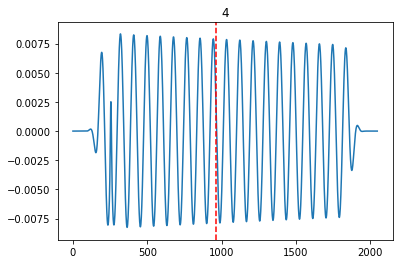

In [1017]:
# ── Quick time-series preview of m_z at the Py edge ───────────────────────────
# Loop over the first 5 time steps and plot m_z along the y-axis
# at the rightmost x-cell (x-index = -1) to inspect the edge dynamics.
# for i in range(np.shape(M1)[0]):   # (disabled) loop over all time steps
for i in range(5):
    clear_output(wait=True)        # Replace previous output (animation-like preview)
    plt.title(i)
    plt.plot(M1[i, 0, :, -1, 2])  # m_z vs y-index at the edge (x = -1) and z-layer 0
    # Symmetric y-axis limits based on the global maximum of m_z at the edge
    plt.ylim(
        -1 * np.abs(M1[:, 0, :, -1, 2]).max(),
         np.abs(M1[:, 0, :, -1, 2]).max()
    )
    plt.axvline(960, c='r', ls='--')  # Mark y-index 960 (reference position near the edge)
    plt.show()


In [1018]:
# ── Peak m_z amplitude at y-index 960 across all time steps ──────────────────
# Compute the maximum absolute value of m_z at the fixed y-index 960
# (near the Py layer edge) across all recorded time steps.
# Result is multiplied by 1e3 to convert to milli-units.
np.max(np.abs(M1[:, 0, 960, -1, 2])) * 1e3


7.872100919485092

In [1019]:
# ── Rough frequency shift estimate ────────────────────────────────────────────
# Compute the relative difference between two candidate edge-mode frequencies
# (e.g., 6.88 GHz vs 6.72 GHz) as a percentage.
# This is a quick manual check; the values are likely read from dispersion data.
((6.88 - 6.72) / 6.88) * 100


2.325581395348839

In [1020]:
# ── Build list of simulation output directories for a given amplitude ─────────
amp = "0.0300"   # Target excitation amplitude string used in directory names

# Base directory containing all edge-mode simulations at B = 300 mT
dir0 = r"D:\mumax3\inelastic_scattering\k_pos\edge_modes\\"

# Glob for all simulation runs at this amplitude, sorted by frequency
dirLi = sorted(
    glob.glob(dir0 + "//B_300mT_edge_f_*GHz_amp_" + amp + ".out")
)


In [1021]:
# ── (Disabled) Hard-coded directory list for debugging / reproducibility ──────
# Uncomment to override the glob search with explicit paths at amp = 0.0003
# dirLi = [
#     'D:\\mumax3\\inelastic_scattering\\k_pos\\edge_modes\\B_300mT_edge_f_11.0GHz_amp_0.0003.out',
#     'D:\\mumax3\\inelastic_scattering\\k_pos\\edge_modes\\B_300mT_edge_f_11.5GHz_amp_0.0003.out',
# ]


In [1022]:
# ── Inspect the current directory list ────────────────────────────────────────
# Display dirLi to confirm the correct files were found by the glob.
# The commented lines below show the expected output for reference.
dirLi
# = ['D:\\mumax3\\inelastic_scattering\\k_pos\\edge_modes\\B_300mT_edge_f_11.0GHz_amp_0.0300.out',
#    'D:\\mumax3\\inelastic_scattering\\k_pos\\edge_modes\\B_300mT_edge_f_11.5GHz_amp_0.0300.out' ]


['D:\\mumax3\\inelastic_scattering\\k_pos\\edge_modes\\B_300mT_edge_f_11.0GHz_amp_0.0300.out',
 'D:\\mumax3\\inelastic_scattering\\k_pos\\edge_modes\\B_300mT_edge_f_11.5GHz_amp_0.0300.out',
 'D:\\mumax3\\inelastic_scattering\\k_pos\\edge_modes\\B_300mT_edge_f_12.0GHz_amp_0.0300.out',
 'D:\\mumax3\\inelastic_scattering\\k_pos\\edge_modes\\B_300mT_edge_f_12.5GHz_amp_0.0300.out',
 'D:\\mumax3\\inelastic_scattering\\k_pos\\edge_modes\\B_300mT_edge_f_13.0GHz_amp_0.0300.out',
 'D:\\mumax3\\inelastic_scattering\\k_pos\\edge_modes\\B_300mT_edge_f_13.5GHz_amp_0.0300.out',
 'D:\\mumax3\\inelastic_scattering\\k_pos\\edge_modes\\B_300mT_edge_f_14.0GHz_amp_0.0300.out',
 'D:\\mumax3\\inelastic_scattering\\k_pos\\edge_modes\\B_300mT_edge_f_14.5GHz_amp_0.0300.out',
 'D:\\mumax3\\inelastic_scattering\\k_pos\\edge_modes\\B_300mT_edge_f_15.0GHz_amp_0.0300.out',
 'D:\\mumax3\\inelastic_scattering\\k_pos\\edge_modes\\B_300mT_edge_f_15.5GHz_amp_0.0300.out',
 'D:\\mumax3\\inelastic_scattering\\k_pos\\edge_mo

In [14]:
# ── Restrict analysis to a single frequency for detailed inspection ───────────
# Override dirLi to process only the 11.0 GHz simulation.
# Remove or comment this cell to process all frequencies found by the glob.
dirLi = [
    'D:\\mumax3\\inelastic_scattering\\k_pos\\edge_modes\\B_300mT_edge_f_11.0GHz_amp_0.0300.out',
]


Reading folder: D:\mumax3\inelastic_scattering\k_pos\edge_modes\B_300mT_edge_f_11.0GHz_amp_0.0300.out/m*.ovf
N of files to process:  1
Available nodes (n-1): 31
Matrix shape: (1, 1, 2048, 128, 3)


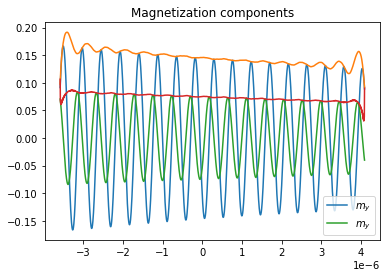

C:\ProgramData\Anaconda3\lib\site-packages\scipy\optimize\minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


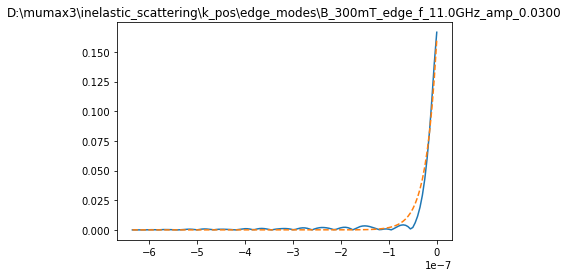

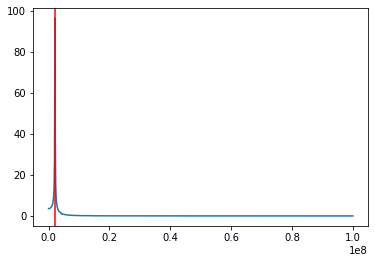

In [15]:
# ── Main analysis loop: extract edge-mode parameters for each frequency ────────
# For every simulation in dirLi this loop extracts:
#   • ratios_old  – m_y / m_z ellipticity via Hilbert envelope at the array midpoint
#   • ratios      – m_y / m_z ellipticity via exponential decay fits
#   • alpha       – spatial decay rate K (m⁻¹) of the edge mode
#   • amp         – edge-mode amplitude (m_z envelope at the array midpoint)
#   • k           – dominant wave-vector k_y (rad/m) from FFT of m_y
#   • edge_nu     – excitation frequency (GHz) parsed from the filename

plt.rcParams.update({'font.size': 10})

# Initialise result lists
amp         = []
ratios_old  = []
ratios      = []
alpha       = []
k           = []
edge_nu     = []

for path0 in dirLi:

    # ── Load OVF data (last time step only: tStart=-1) ─────────────────────────
    parms    = parameters.ovfParms(head='m', tStart=-1)
    M_txyzm  = ovf.OvfFile(path0, parms)
    cy = (M_txyzm._headers)['ystepsize']
    cx = (M_txyzm._headers)['xstepsize']

    # Spatial coordinate arrays centred at zero
    y = np.arange(0, np.shape(M_txyzm.array)[2], 1) * cy
    y -= np.mean(y)

    # x is shifted so that x = 0 is at the Py edge (right boundary)
    x = np.arange(0, np.shape(M_txyzm.array)[3], 1) * cx
    x -= np.max(x)   # x ≤ 0: distance into the film from the edge

    M1  = M_txyzm.array

    # Parse excitation frequency from the filename string (e.g. "11.0GHz")
    nu = float(path0.split("\\")[-1].split("_")[-3][:-3])
    edge_nu.append(nu)

    # ── Method 1: Ellipticity from Hilbert envelope ratio at y midpoint ────────
    # Select a central y-window (15 %–90 % of the array) to avoid edge artefacts
    y0    = int(2048 * 0.15)
    y1    = int(2048 * 0.9)
    y_i   = y[y0:y1]

    plt.title("Magnetization components")

    # m_y component and its amplitude envelope (Hilbert transform)
    my                  = M1[0, 0, y0:y1, -1, 1]
    analytic_signal_my  = np.abs(hilbert(my))
    sh                  = analytic_signal_my.shape[0] // 2   # Midpoint index

    plt.plot(y[y0:y1], my,                 label=r"$m_{y}$")
    plt.plot(y[y0:y1], analytic_signal_my)

    # m_z component and its amplitude envelope
    mz                  = M1[0, 0, y0:y1, -1, 2]
    analytic_signal_mz  = np.abs(hilbert(mz))

    plt.plot(y[y0:y1], mz,                 label=r"$m_{y}$")
    plt.plot(y[y0:y1], analytic_signal_mz)

    plt.legend()
    plt.show()

    # Ellipticity = my_envelope / mz_envelope evaluated at the window midpoint
    ratios_old.append(analytic_signal_my[sh] / analytic_signal_mz[sh])


    # ── Method 2: Ellipticity from exponential decay fits ──────────────────────
    # Locate the y-row with the maximum m_y amplitude in the lower half of the array
    # (cut_ind splits the array; cut_ind_2 finds the peak within that half)
    cut_ind   = np.shape(M1)[2] // 2
    cut_ind_2 = findNearest(
        M1[0, 0, cut_ind:, -1, 1],
        np.amax(M1[0, 0, cut_ind:, -1, 1])
    )[0]

    # Extract the x-profile of |m_y| at the peak-amplitude y-row
    cut_y = np.abs(M1[0, 0, cut_ind + cut_ind_2, :, 1])
    # Fit exponential decay; skip first 64 cells near the edge to avoid near-field artefacts
    popt_y, pcon = curve_fit(fun, x[64:], cut_y[64:], p0=(0e-6, 0e-9, -4.4e7))
    fit_y = fun(x, *popt_y)

    # Same procedure for m_z
    cut_ind_2 = findNearest(
        M1[0, 0, cut_ind:, -1, 2],
        np.amax(M1[0, 0, cut_ind:, -1, 2])
    )[0]
    cut_z = np.abs(M1[0, 0, cut_ind + cut_ind_2, :, 2])
    popt_z, pcon = curve_fit(fun, x[64:], cut_z[64:], p0=(0e-6, 0e-9, -4.4e7))
    fit_z = fun(x, *popt_z)

    # Ellipticity = spatial average of the fit_y / fit_z ratio along x
    ratios.append(np.mean(fit_y / fit_z))


    # ── Decay coefficient extraction ───────────────────────────────────────────
    # Use a different starting y-row (cell 256) for a more conservative estimate
    # of the edge-mode spatial decay rate K.
    cut_ind   = 256
    cut_ind_2 = findNearest(
        M1[0, 0, cut_ind:, -1, 1],
        np.amax(M1[0, 0, cut_ind:, -1, 1])
    )[0]
    cut = np.abs(M1[0, 0, cut_ind + cut_ind_2, :, 1])

    # Fit exp decay model; popt[2] = K (the decay rate in m⁻¹)
    popt, pcon = curve_fit(fun, x[64:], cut[64:], p0=(0e-6, 0e-9, -4.4e7))
    alpha.append(popt[2])

    plt.title(path0.split("/")[-1][:-4])
    plt.plot(x, cut)
    plt.plot(x, fun(x, *popt), ls="--")   # Overlay the fitted curve
    plt.show()


    # ── Edge-mode amplitude ────────────────────────────────────────────────────
    # Re-use the central y-window and evaluate the Hilbert envelope of m_z
    # at the midpoint as a proxy for the edge-mode amplitude.
    y0  = int(2048 * 0.15)
    y1  = int(2048 * 0.9)
    y_i = y[y0:y1]
    my  = M1[0, 0, y0:y1, -1, 1]
    mz  = M1[0, 0, y0:y1, -1, 2]
    analytic_signal_my = np.abs(hilbert(my))
    analytic_signal_mz = np.abs(hilbert(mz))
    sh  = analytic_signal_mz.shape[0] // 2
    amp.append(analytic_signal_mz[sh])


    # ── Edge-mode wave-vector k_y via FFT of m_y ───────────────────────────────
    # Compute the 1-D FFT of m_y along the y-direction and identify the peak
    # spatial frequency as the dominant propagation wave-vector.
    sp    = np.fft.fft(my)
    k_vec = np.fft.fftfreq(y_i.shape[-1], y_i[1] - y_i[0])   # Frequency axis (rad⁻¹ or cycles/m)
    sh    = k_vec.shape[0] // 2
    k_vec = k_vec[:sh]    # Keep positive frequencies only
    sp    = np.abs(sp)[:sh]
    ki    = k_vec[findNearest(sp, np.amax(sp))[0]]   # Peak frequency = dominant k_y
    k.append(ki)

    plt.plot(k_vec, sp)
    plt.axvline(x=ki, c="r")   # Highlight the peak wave-vector
    plt.show()


# ── Convert result lists to NumPy arrays ───────────────────────────────────────
edge_nu     = np.array(edge_nu)
ratios_old  = np.array(ratios_old)
ratios      = np.array(ratios)
amp         = np.array(amp)
alpha       = np.array(alpha)
k           = np.array(k)


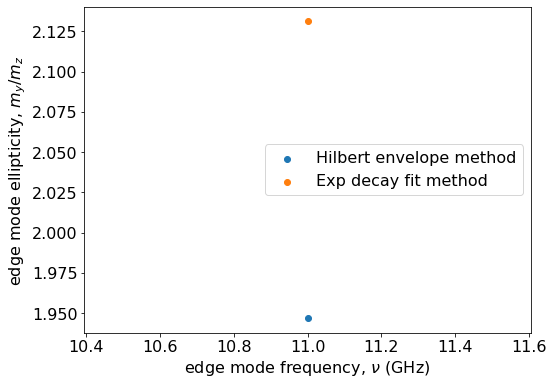

In [16]:
# ── Plot edge-mode ellipticity vs frequency (comparison of two methods) ────────
# Both methods should yield the same physical quantity m_y / m_z;
# the comparison validates the robustness of each extraction approach.
plt.rcParams.update({'font.size': 16})

plt.figure(figsize=(8, 6))
plt.scatter(edge_nu, ratios_old, label="Hilbert envelope method")
plt.scatter(edge_nu, ratios,     label="Exp decay fit method")
plt.xlabel(r"edge mode frequency, $\nu$ (GHz)")
plt.ylabel(r"edge mode ellipticity, $m_y$/$m_z$")
plt.legend()
plt.show()


In [17]:
# ── Inspect ellipticity values (exp-fit method) ───────────────────────────────
ratios


array([2.13115777])

In [ ]:
# ── Ellipticity profile along the x-direction (across the film thickness) ──────
# For each x-cell index (depth into the Py layer from the edge), compute the
# local m_z / m_y amplitude ratio using Hilbert envelopes and a linear background fit.
# This reveals how the ellipticity varies with distance from the Py edge.

ellipsis_hil = []   # Ellipticity m_z/m_y as a function of x-index
mz_li        = []   # m_z amplitude at the y-window midpoint vs x
my_li        = []   # m_y amplitude at the y-window midpoint vs x

for i in range(np.shape(M1)[3]):   # Iterate over all x-cells (depth profile)

    # Select a central y-window (30 %–70 %) to stay away from the simulation boundaries
    y0  = int(2048 * 0.3)
    y1  = int(2048 * 0.7)
    y_i = y[y0:y1]

    # Extract in-plane (m_x, m_y) and out-of-plane (m_z) components at this x-cell
    mx = M1[0, 0, y0:y1, i, 0]
    analytic_signal_mx = np.abs(hilbert(mx))

    my = M1[0, 0, y0:y1, i, 1]
    analytic_signal_my = np.abs(hilbert(my))

    mz = M1[0, 0, y0:y1, i, 2]
    analytic_signal_mz = np.abs(hilbert(mz))

    # Fit a linear trend to the Hilbert envelopes to remove the slow gradient
    # that arises because the edge mode has a k-vector along y.
    offset = 25   # Exclude 25 cells at each end to reduce boundary effects
    popt_my, __ = curve_fit(lin_fun, y_i[offset:-1*offset], analytic_signal_my[offset:-1*offset])
    popt_mz, __ = curve_fit(lin_fun, y_i[offset:-1*offset], analytic_signal_mz[offset:-1*offset])

    my_amp_fit = lin_fun(y_i, *popt_my)   # Linearised m_y amplitude along y
    mz_amp_fit = lin_fun(y_i, *popt_mz)   # Linearised m_z amplitude along y

    # Diagnostic plot every 10 cells (and always for the last x-cell)
    if i % 10 == 0 or i == 127:
        plt.title(i)
        plt.scatter(y_i, analytic_signal_mz)    # Raw Hilbert envelope
        plt.plot(y_i, mz)                        # Raw m_z oscillation
        plt.plot(y_i, mz_amp_fit)                # Linear amplitude fit
        plt.show()

    # Evaluate amplitudes at the midpoint of the y-window
    sh = y_i.shape[0] // 2
    ellipsis_hil.append(mz_amp_fit[sh] / my_amp_fit[sh])   # Ellipticity = m_z/m_y
    mz_li.append(mz_amp_fit[sh])
    my_li.append(my_amp_fit[sh])

# Convert to arrays (indexed by x-cell = distance from the Py edge)
ellipsis_hil = np.array(ellipsis_hil)
mz_li        = np.array(mz_li)
my_li        = np.array(my_li)


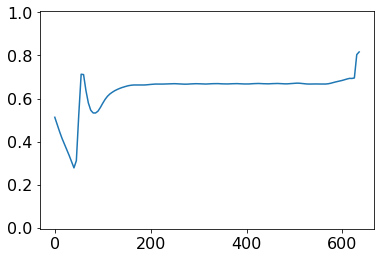

In [19]:
# ── Plot ellipticity profile as a function of depth into the film ──────────────
# x-axis: distance from the Py edge (nm)
# y-axis: m_z / m_y (should approach the bulk value far from the edge)
plt.plot(np.abs(x) * 1e9, ellipsis_hil)
# plt.xlim(0, 200)
plt.ylim(-0.005, 1.005)
plt.show()


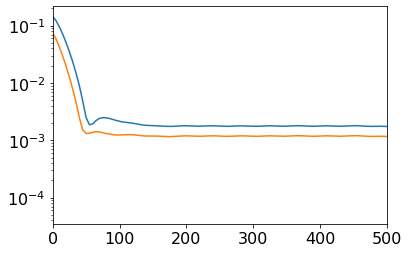

In [20]:
# ── Log-scale amplitude profiles of m_y and m_z vs depth ─────────────────────
# A straight line on a log-scale confirms the exponential decay of each component.
# The slope gives the decay rate K for m_y and m_z independently.
plt.plot(np.abs(x) * 1e9, my_li)
plt.plot(np.abs(x) * 1e9, mz_li)
plt.xlim(0, 500)
plt.yscale("log")
plt.show()


In [21]:
# ── Load demagnetising field from a separate Mumax3 simulation ────────────────
# This simulation uses a 4096-cell grid with 5 nm cell size and 10 nm Py thickness.
# The demagnetising field B_demag is read at the first (and only) saved time step.
dir0 = r"D:\mumax3\inelastic_scattering\dispersion\edge_mode_dispersion_4096_05nm_cz_10nm_higher_modes_antenna_w_10nm.out"

parms           = parameters.ovfParms(head="B_demag000000")
B_demag_cz_10nm = ovf.OvfFile(dir0, parms)

print((B_demag_cz_10nm.array).shape)   # Confirm array dimensions
B_demag_cz_10nm = B_demag_cz_10nm.array[:, :, :, :, :]


Reading folder: D:\mumax3\inelastic_scattering\dispersion\edge_mode_dispersion_4096_05nm_cz_10nm_higher_modes_antenna_w_10nm.out/B_demag000000*.ovf
N of files to process:  1
Available nodes (n-1): 31
Matrix shape: (1, 1, 4096, 128, 3)
(1, 1, 4096, 128, 3)


In [22]:
# ── Build x-coordinate array for the demagnetising field simulation ───────────
cx = 5e-9    # Cell size: 5 nm
xx = np.arange(0, B_demag_cz_10nm.shape[3] * cx - cx / 10, cx)
xx -= xx.max()   # Shift so that xx = 0 is at the Py edge (all values ≤ 0 inside the film)
# x  -= x.max()  # (equivalent shift for the magnetisation coordinate array)


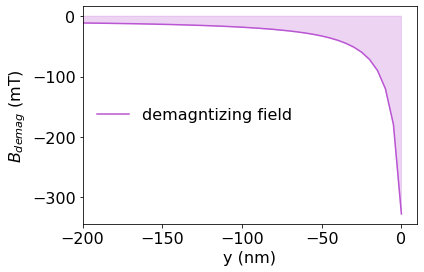

In [23]:
# ── Plot the demagnetising field profile near the Py edge ─────────────────────
# The field B_y^d has a characteristic well shape that confines the edge mode.
# Row index 2048 corresponds to the centre of the simulation box in y.
color = "mediumorchid"
plt.plot(
    xx * 1e9,
    B_demag_cz_10nm[0, 0, 2048, :, 0] * 1e3,   # B_x component in mT
    color=color, label="demagntizing field"
)
plt.fill_between(xx * 1e9, B_demag_cz_10nm[0, 0, 2048, :, 0] * 1e3, color=color, alpha=0.25)

plt.xlim(-200, 10)
plt.xlabel("y (nm)")
plt.ylabel(r"$B_{demag}$ (mT)")
plt.legend(loc="center left", frameon=False)
# plt.savefig(r"C:\Users\admin\Desktop\B_demag.pdf", bbox_inches='tight',pad_inches = 0,dpi=600)
plt.show()


In [24]:
# ── Quick check: midpoint y-index of the magnetisation array ─────────────────
# Half the y-dimension of M1; used below as the starting row for decay fits.
np.shape(M1)[2] // 2


1024

In [25]:
# ── Exponential decay fits for m_y and m_z components (standalone cell) ───────
# Fits the spatial x-profile of m_y and m_z at the y-row of maximum amplitude.
# Results (fit_y, fit_z) are used in subsequent plotting cells.

# ── m_y component ─────────────────────────────────────────────────────────────
cut_ind   = np.shape(M1)[2] // 2   # Start search in the lower half of the y-array
cut_ind_2 = findNearest(
    M1[0, 0, cut_ind:, -1, 1],
    np.amax(M1[0, 0, cut_ind:, -1, 1])
)[0]   # y-index of peak m_y amplitude (relative to cut_ind)

cut_y = M1[0, 0, cut_ind + cut_ind_2, :, 1]   # x-profile of m_y at the peak row
popt_y, pcon = curve_fit(fun, x[64:], cut_y[64:], p0=(0e-6, 0e-9, -4.4e7))
fit_y = fun(x, *popt_y)   # Fitted exponential profile for m_y

# ── m_z component ─────────────────────────────────────────────────────────────
cut_ind_2 = findNearest(
    M1[0, 0, cut_ind:, -1, 2],
    np.amax(M1[0, 0, cut_ind:, -1, 2])
)[0]

cut_z = np.abs(M1[0, 0, cut_ind + cut_ind_2, :, 2])
popt_z, pcon = curve_fit(fun, x[64:], cut_z[64:], p0=(0e-6, 0e-9, -4.4e7))
fit_z = fun(x, *popt_z)   # Fitted exponential profile for m_z

# ellipsis = fit_z/fit_y  # (disabled) pointwise ellipticity from the decay fits

# ── (Disabled) diagnostic plots ───────────────────────────────────────────────
# plt.title(r"$m_y$")
# plt.plot( x*1e9, cut_y  )
# plt.plot( x*1e9, fit_y, ls="--" )
# plt.show()

# plt.title(r"$mz$")
# plt.plot( x*1e9, cut_z  )
# plt.plot( x*1e9, fit_z, ls="--" )
# plt.show()


C:\ProgramData\Anaconda3\lib\site-packages\scipy\optimize\minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


In [27]:
# ── (Disabled) overlay of ellipticity profiles from both methods ──────────────
# Uncomment to compare:
#   - pointwise ratio fit_z/fit_y from exponential decay fits
#   - ellipsis_hil from Hilbert envelope linear fits
# plt.title(r"ellipticity")
# plt.plot( np.abs(x)*1e9, ellipsis,   label="Exp decay fit method")
# plt.plot( np.abs(x)*1e9, ellipsis_hil, label="Hilbert envelope method")
# plt.legend()
# plt.show()


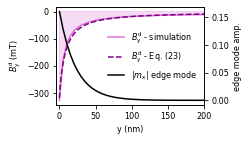

In [36]:
# ── Publication-quality figure: demagnetising field + edge-mode amplitude ──────
# Dual-axis plot combining:
#   Left  y-axis (orchid):  analytical demagnetising field B_y^d(y) from simulation
#                            and the fit using B_demag_fun (Eq. 23 in the paper)
#   Right y-axis (black):   exponentially decaying edge-mode amplitude from the fit
# The spatial alignment shows how the demagnetising field well near the Py edge
# confines and shapes the edge spin-wave mode.

plt.rcParams.update({'font.size': 8})
fig, ax1 = plt.subplots(figsize=(3.5, 2))   # Small figure for publication (column width)

# ── Left axis: demagnetising field ────────────────────────────────────────────
color1 = "orchid"
x1 = np.abs(xx) * 1e9 + 1e-6    # Distance from edge in nm (small offset avoids log(0))
xx1 = np.linspace(x1.min(), x1.max(), int(1e4))   # Fine grid for smooth analytical curve
y1 = B_demag_cz_10nm[0, 0, 2048, :, 0] * 1e3     # Simulated B_y^d in mT

# Fit the analytical demagnetising field formula to the simulation data
popt_demag, pcov = curve_fit(B_demag_fun, x1, y1, p0=(-600, 20))

ax1.plot(x1, y1, color=color1, label=r"$B_\mathrm{y}^\mathrm{d}$ - simulation")
ax1.fill_between(x1, y1, color=color1, alpha=0.25)
ax1.plot(xx1, B_demag_fun(xx1, *popt_demag), color="purple", ls="--",
         label=r"$B_\mathrm{y}^\mathrm{d}$ - Eq. (23)")
ax1.set_xlabel("y (nm)")
ax1.set_ylabel(r"$B_\mathrm{y}^\mathrm{d}$ (mT)")
ax1.tick_params(axis='y')

# ── Right axis: edge-mode amplitude ───────────────────────────────────────────
ax2 = ax1.twinx()   # Share the x-axis with ax1

x2 = np.abs(x) * 1e9          # Distance from Py edge in nm
y2 = fun(x, *popt)             # Fitted exponential edge-mode amplitude
color2 = "black"

ax2.plot(x2, y2, color=color2, ls="solid", label="|$m_\mathrm{x}$| edge mode")
# ax2.plot(x2, cut_y, color="blue", ls="solid", label="|$m_\mathrm{x}$| edge mode")  # raw data alternative
ax2.set_ylabel(r"edge mode amp.", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_xlim(-5, 200)   # Show the first 200 nm from the edge

# Merge legends from both axes into a single legend on ax1
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", frameon=False)

plt.tight_layout()
# plt.savefig(r"C:\Users\admin\Desktop\B_demag_and_edge_mode.pdf",
#             bbox_inches='tight', pad_inches=0, dpi=600)
plt.show()


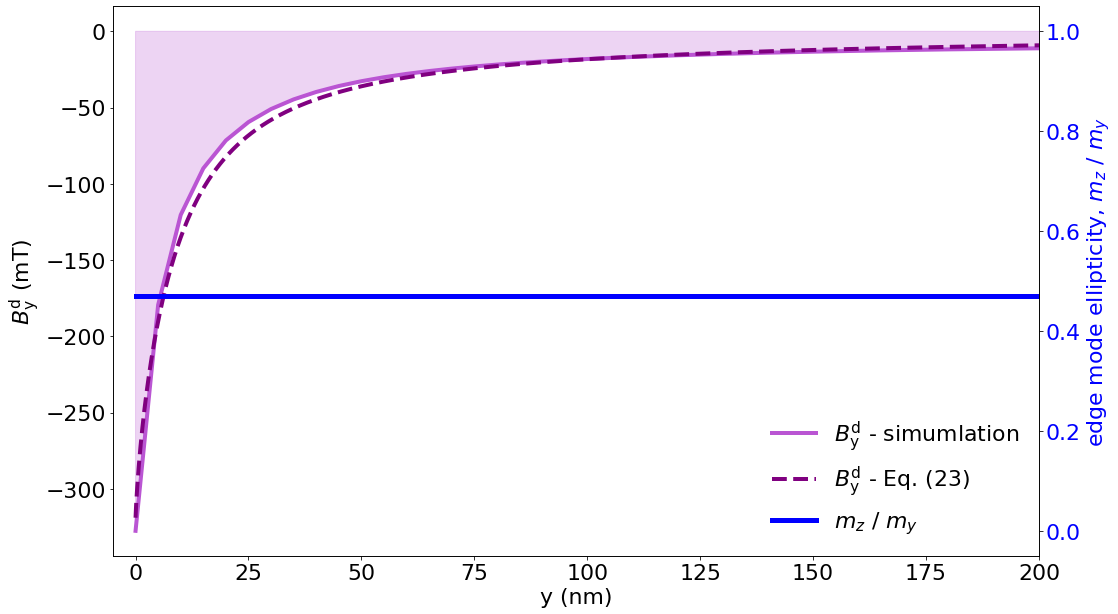

In [876]:
# ── Large figure: demagnetising field + edge-mode ellipticity ─────────────────
# Same dual-axis layout as the publication figure above, but larger (16×9 inch)
# and with ellipticity m_z/m_y on the right axis instead of raw amplitude.
# This directly visualises the connection between the field confinement well
# and the spatial variation of the mode polarisation ellipse.

plt.rcParams.update({'font.size': 22})
fig, ax1 = plt.subplots(figsize=(16, 9))

# ── Left axis: demagnetising field ────────────────────────────────────────────
color1 = "mediumorchid"
x1 = np.abs(xx) * 1e9
y1 = B_demag_cz_10nm[0, 0, 2048, :, 0] * 1e3
lw = 4

ax1.plot(x1, y1, color=color1, lw=lw, label=r"$B_\mathrm{y}^\mathrm{d}$ - simulation")
ax1.plot(xx1, B_demag_fun(xx1, *popt_demag), color="purple", lw=lw, ls="--",
         label=r"$B_\mathrm{y}^\mathrm{d}$ - Eq. (23)")
ax1.fill_between(x1, y1, color=color1, alpha=0.25)
ax1.set_xlabel("y (nm)")
ax1.set_ylabel(r"$B_\mathrm{y}^\mathrm{d}$ (mT)")
ax1.tick_params(axis='y')

# ── Right axis: ellipticity m_z / m_y ─────────────────────────────────────────
ax2 = ax1.twinx()

x2 = np.abs(x) * 1e9
y2 = fun(x, *popt)   # (unused in plot; ellipsis array is plotted instead)
color2 = "blue"
lw = 5

# ellipsis is the pointwise ratio fit_z/fit_y computed in Cell 25
ax2.plot(x2, ellipsis, color=color2, lw=lw, ls="solid", label=r"$m_z$ / $m_y$")
ax2.set_ylabel(r"edge mode ellipticity, $m_z$ / $m_y$", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(-0.05, 1.05)

ax1.set_xlim(-5, 200)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right", frameon=False)

plt.tight_layout()
# plt.savefig(r"C:\Users\admin\Desktop\B_demag_and_mode_ellipticity_nu_{}GHz.jpg".format(nu),
#             bbox_inches='tight', pad_inches=0, dpi=600)
plt.show()


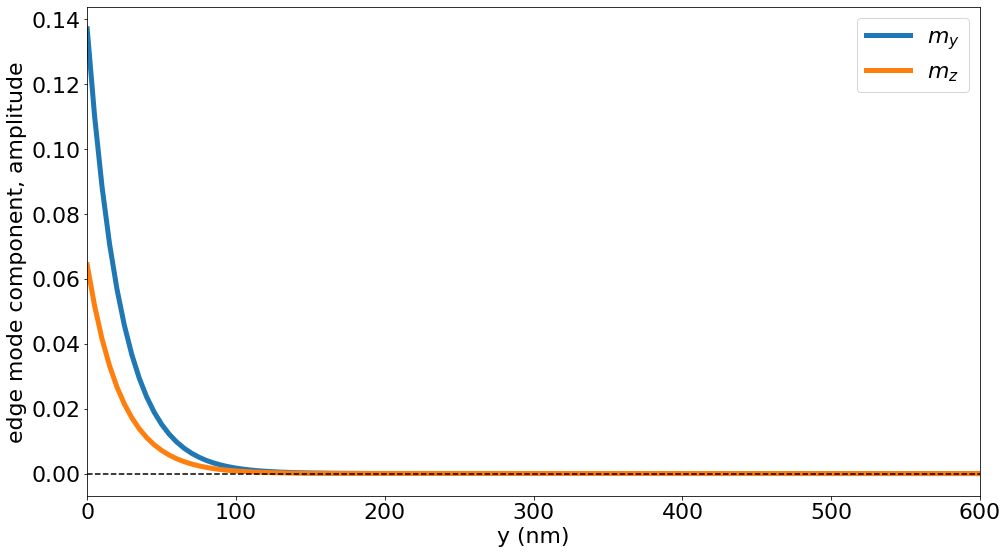

In [882]:
# ── Plot fitted exponential profiles of m_y and m_z vs distance from the edge ──
# Shows the spatial extent of the two magnetisation components of the edge mode.
# Both components decay exponentially away from the Py edge; the ratio fit_y/fit_z
# is the ellipticity plotted in the previous cells.
lw = 5

plt.figure(figsize=(16, 9))
plt.plot(np.abs(x) * 1e9, fit_y, lw=lw, label=r"$m_y$")
plt.plot(np.abs(x) * 1e9, fit_z, lw=lw, label=r"$m_z$")
# plt.yscale("log")   # Uncomment to verify linearity on log scale (pure exponential)

plt.xlim(0, 600)
plt.xlabel("y (nm)")
# plt.ylim(1e-3, 2.5e-3)
plt.ylabel(r"edge mode component, amplitude")
plt.axhline(y=0.0, c="k", ls="--")   # Zero reference line
plt.legend()
plt.savefig(
    r"C:\Users\admin\Desktop\mode_components_nu_{}GHz.jpg".format(nu),
    bbox_inches='tight', pad_inches=0, dpi=600
)
plt.show()
